# Telescope Observation with SPHEREx (W5)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import SPHERExobserver as so
import synthesizer as sy
import pickle as pk
import unyt as u
from astropy.cosmology import Planck18 as cosmo
import healpy as hp
import pandas as pd
import matplotlib.colors as cm
from synthesizer.instruments import premade
from synthesizer import Grid


grid_dir="grids/"
grid="test_grid"
grid=Grid(grid_name=grid,
             grid_dir=grid_dir)


/home/kaistanyard/SPHERExobserver.py:4: FutureWarning: The filters module has been moved to the instruments module. Please update your imports synthesizer.filters -> synthesizer.instruments
  from synthesizer.filters import FilterCollection,Filter


## Instruments

In [2]:
#SPHEREx
SPHEREX=so.SPHEREx_instrument()

#JWST
print(f"JWST: {premade.JWSTNIRCamWide.available_filters}")
JWST_codes=['JWST/NIRCam.F070W','JWST/NIRCam.F115W','JWST/NIRCam.F200W']
JWST_L_codes=['JWST/NIRCam.F277W','JWST/NIRCam.F356W','JWST/NIRCam.F444W']

JWST=sy.filters.FilterCollection(JWST_codes)
JWST_L=sy.filters.FilterCollection(JWST_L_codes)

#Euclid
print(f"Euclid: {premade.EuclidNISP.available_filters}")
euclid_codes=['Euclid/NISP.Y', 'Euclid/NISP.J', 'Euclid/NISP.H']
EUCLID=sy.filters.FilterCollection(euclid_codes)

JWST: ['JWST/NIRCam.F070W', 'JWST/NIRCam.F090W', 'JWST/NIRCam.F115W', 'JWST/NIRCam.F150W', 'JWST/NIRCam.F200W', 'JWST/NIRCam.F277W', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F444W']
Euclid: ['Euclid/NISP.Y', 'Euclid/NISP.J', 'Euclid/NISP.H']


## Importing a galaxy

In [3]:
#Open a Galaxy Object from TNG simulations
id="288"
galaxy=pk.load(open(f'Examples/data/galaxy_{id}.pck','rb'))


## Spectra

In [4]:
#The Emission Model
model=sy.emission_models.IntrinsicEmission(
    grid=grid,
    per_particle=True
)

#Generate SED
sed=galaxy.get_spectra(model)

#Will take a while to run

## Pixel and Image Properties

In [35]:
#Pixel sizes in arc seconds
S_pix=6.2 #SPHEREx
J_pix=0.031 #JWST NIRCam short wavelengh
JL_pix=0.063 #JWST NIRCam Long Wavelengh
U_pix=0.3  #EUCLID NISP

#Image observed angular size in arcseconds
image_ang_width=41.33
#Note some values are not valid due to rounding issues (this needs fixing)
#Tested and work : 41.33,82.66

#Image type
img_type="hist"

#Parameters for smoothing
smooth_lengh=0.001
threshold=1


#Image physical size
width=(1.25/2)*u.kpc

#Convert pixel sise to number of pixels 
def Psize2npix(size,image_ang_width):
    npix=image_ang_width/size
    return npix

#Calculate Resolution of the images
S_res=width/Psize2npix(S_pix,image_ang_width)
J_res=width/Psize2npix(J_pix,image_ang_width)
U_res=width/Psize2npix(U_pix,image_ang_width)
JL_res=width/Psize2npix(JL_pix,image_ang_width)


## Imaging

In [38]:
#SPHEREx

galaxy.get_photo_lnu(SPHEREX,
                     nthreads=-1)
imgs=galaxy.get_images_luminosity(
    resolution=S_res,
    fov=width,
    emission_model=model,
    img_type=img_type
    
    )

SPHEREX_rgb=imgs.make_rgb_image(rgb_filters={
                                "R":["filter1"],
                                "G":["filter50"],
                                "B":["filter100"]}
                                )
vmin=-np.percentile(SPHEREX_rgb, 32)
vmax=np.percentile(SPHEREX_rgb, 99.9)
norm=cm.Normalize(vmin=vmin, vmax=vmax, clip=True)
SPHEREX_rgb=norm(SPHEREX_rgb)
#Will take a while to run

In [39]:
#JWST NIRCam (Short) Smoothed
galaxy.get_photo_lnu(JWST)
galaxy.stars.smoothing_lengths=np.full(galaxy.stars.nparticles,smooth_lengh)*u.kpc

imgs=galaxy.get_images_luminosity(
    resolution=J_res,
    fov=width,
    emission_model=model,
    kernel=galaxy.stars.smoothing_lengths,
    kernel_threshold=threshold,

    )



JWST_rgb=imgs.make_rgb_image(rgb_filters={
                                "R":["JWST/NIRCam.F070W"],
                                "G":["JWST/NIRCam.F115W"],
                                "B":["JWST/NIRCam.F200W"]}
                                )
vmin = -np.percentile(JWST_rgb, 32)
vmax = np.percentile(JWST_rgb, 99.9)
norm = cm.Normalize(vmin=vmin, vmax=vmax, clip=True)
JWST_rgb=norm(JWST_rgb)


In [40]:
#Euclid NISP
galaxy.get_photo_lnu(EUCLID)
imgs=galaxy.get_images_luminosity(
    resolution=U_res,
    fov=width,
    emission_model=model,
    img_type=img_type,
    )
EUCLID_rgb=imgs.make_rgb_image(rgb_filters={
                                "R":['Euclid/NISP.Y'],
                                "G":['Euclid/NISP.J'],
                                "B":['Euclid/NISP.H']}
                                )
vmin = -np.percentile(EUCLID_rgb, 32)
vmax = np.percentile(EUCLID_rgb, 99.9)
norm = cm.Normalize(vmin=vmin, vmax=vmax, clip=True)
EUCLID_rgb=norm(EUCLID_rgb)

In [41]:
#JWST NIRCam (Long) smoothed
galaxy.get_photo_lnu(JWST_L)
galaxy.stars.smoothing_lengths=np.full(galaxy.stars.nparticles,smooth_lengh)*u.kpc
imgs=galaxy.get_images_luminosity(
    resolution=JL_res,
    fov=width,
    emission_model=model,
    kernel=galaxy.stars.smoothing_lengths,
    kernel_threshold=threshold,
    
    )
JWST_L_rgb=imgs.make_rgb_image(rgb_filters={
                                "R":['JWST/NIRCam.F277W'],
                                "G":['JWST/NIRCam.F356W'],
                                "B":['JWST/NIRCam.F444W']}
                                )
vmin = -np.percentile(JWST_L_rgb, 32)
vmax = np.percentile(JWST_L_rgb, 99.9)
norm = cm.Normalize(vmin=vmin, vmax=vmax, clip=True)
JWST_L_rgb=norm(JWST_L_rgb)

## Plotting Images

Text(0, -0.1, 'Image angular size is 41.33 arc-seconds, Image physical width is 0.625 kpc. Galaxy is at z=0.503047523244883.')

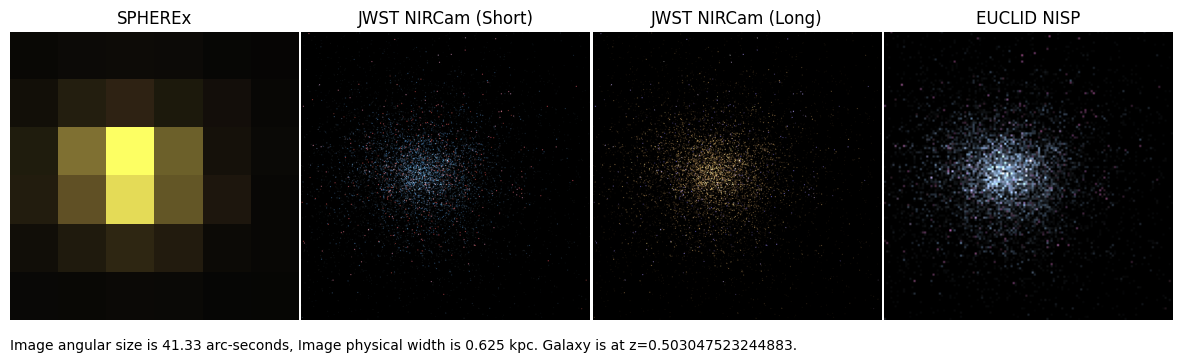

In [42]:
fig,ax=plt.subplots(1,4,figsize=(15,5))


titles=["SPHEREx","JWST NIRCam (Short)","JWST NIRCam (Long)","EUCLID NISP"]
images=[SPHEREX_rgb,JWST_rgb,JWST_L_rgb,EUCLID_rgb]
fig.subplots_adjust(wspace=0.01)

for n in range(4):
    ax[n].set_title(titles[n])
    ax[n].imshow(images[n])
    ax[n].set_axis_off()


info=f"Image angular size is {image_ang_width} arc-seconds, Image physical width is {width}. Galaxy is at z={galaxy.redshift}."
ax[0].text(0,-0.1,info,transform=ax[0].transAxes)#Yes i know these numbers dont mathematically work 


### Saves image to a file

In [43]:
image_dir="" #Add your own here

fig.savefig(f"{image_dir} TelescopeObservation{id}")

